[![](imagens/colab-badge.png){width="16%"}](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap03/cap03_aluno.ipynb) 
[![](imagens/github-badge.png){width="20%"}](https://github.com/fzampirolli/pdi-vc)

# Capitulo 3 -- Filtragem Espacial e Morfologia Matematica

> *"Se os Capitulos 1 e 2 ensinaram voce a **ver** uma imagem, este capitulo ensina a **transforma-la** com intencao."*

## 3.1 Objetivos

Ao final deste capitulo, voce sera capaz de:

- Compreender a operacao de **convolucao 2D** e a diferenca entre convolucao e correlacao;
- Projetar e aplicar **filtros de suavizacao** (media, gaussiano, mediana) para reducao de ruido;
- Usar **filtros de nitidez** (Laplaciano, Sobel, unsharp masking) para realce de bordas;
- Implementar o **detector de Canny** passo a passo;
- Compreender os fundamentos da **Morfologia Matematica**: erosao, dilatacao, abertura, fechamento;
- Construir **pipelines completos** de pre-processamento -> filtragem -> morfologia;
- Aplicar esses conceitos em **problemas reais** (medicina, documento, satelite).


## 3.2 Por que filtrar?

Imagens capturadas no mundo real nunca chegam perfeitas. Ha sempre:

| Problema | Causa tipica | Solucao neste capitulo |
|---|---|---|
| Ruido granular | Sensor CCD em baixa luz | Filtro Gaussiano / Mediana |
| Bordas borradas | Desfoque optico, movimento | Unsharp Masking, High-Boost |
| Bordas para detectar | Segmentacao, OCR | Sobel, Laplaciano, Canny |
| Pequenos objetos espurios | Segmentacao imperfeita | Erosao + Abertura morfologica |
| Buracos em regioes | Limiarizacao local | Fechamento morfologico |

> Aplicacao motivadora: uma radiografia de torax (NIH/dominio publico) bruta vs. apos pipeline completo de filtragem. A deteccao automatica de pneumonia depende desse pre-processamento.


---
## 3.3 Convolucao Bidimensional

### 3.3.1 Formulacao matematica

A filtragem espacial aplica uma **mascara** (kernel) $w$ de tamanho $m \times n$ a cada pixel
da imagem $f$:

$$g(x,y) = \sum_{s=-a}^{a}\sum_{t=-b}^{b} w(s,t)\, f(x-s,\, y-t)$$

onde $a = (m-1)/2$ e $b = (n-1)/2$.

**Convolucao vs. Correlacao:** na correlacao o kernel *nao* e rotacionado:

$$h(x,y) = \sum_{s=-a}^{a}\sum_{t=-b}^{b} w(s,t)\, f(x+s,\, y+t)$$

Para kernels simetricos (Gaussiano, Laplaciano) as operacoes sao equivalentes.
OpenCV usa correlacao em `filter2D`; `scipy.ndimage.convolve` usa convolucao verdadeira.

### 3.3.2 Estrategias de padding

| Estrategia | Descricao | Quando usar |
|---|---|---|
| `zero` | Preenche com 0 | Simples, mas escurece bordas |
| `reflect` | Espelha os pixels | Bom para filtros de suavizacao |
| `wrap` | Ciclico (toroidal) | Processamento de texturas |
| `nearest` | Repete borda | Evita artefatos escuros |


In [1]:
# Dependencias
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
import cv2
from skimage import data, color, filters, morphology, feature
from skimage.util import random_noise

def show(imgs, titles=None, cmap='gray', figsize=None):
    """Utilitario: exibe lista de imagens lado a lado."""
    n = len(imgs)
    if figsize is None:
        figsize = (4*n, 4)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1: axes = [axes]
    for ax, img, title in zip(axes, imgs, titles or ['']*n):
        ax.imshow(img, cmap=cmap if img.ndim == 2 else None)
        ax.set_title(title, fontsize=11)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


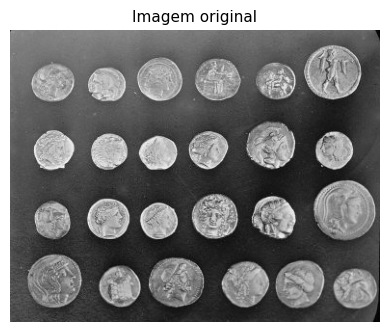

In [14]:
img = data.coins()
show([img], ['Imagem original'])

Diferenca max (manual vs scipy): 6.64e-02


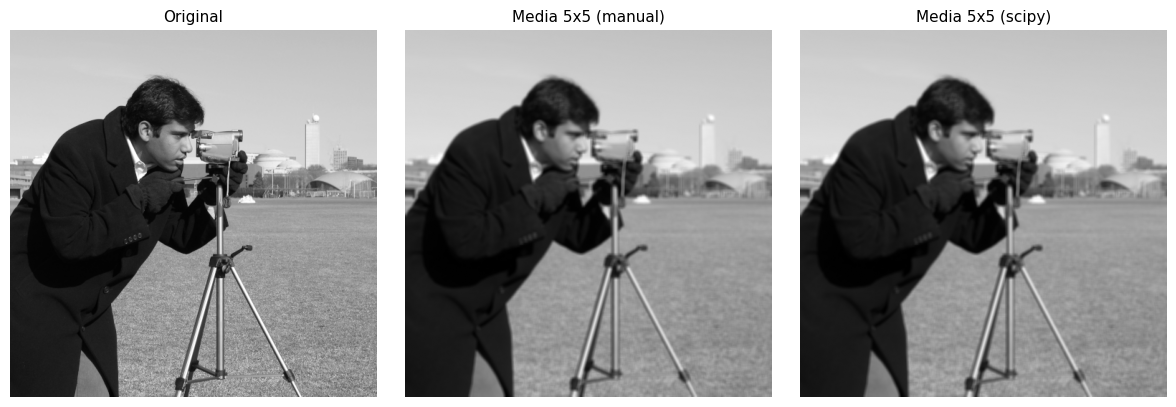

In [15]:
# Convolucao manual vs scipy
img = data.camera().astype(float) / 255.0   # imagem classica (dominio publico)


# Kernel de media 5x5
k_mean = np.ones((5, 5)) / 25.0

def conv2d_manual(image, kernel, pad_mode='reflect'):
    """Convolucao 2D implementada do zero."""
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode=pad_mode)
    out = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            out[i, j] = (padded[i:i+kh, j:j+kw] * kernel).sum()
    return out

manual = conv2d_manual(img, k_mean)
scipy_out = convolve(img, k_mean, mode='reflect')
print(f'Diferenca max (manual vs scipy): {np.abs(manual - scipy_out).max():.2e}')

show([img, manual, scipy_out],
     ['Original', 'Media 5x5 (manual)', 'Media 5x5 (scipy)'])


---
## 3.4 Filtros de Suavizacao (Passa-Baixa)

### 3.4.1 Filtro de Media

$$w = \frac{1}{9}\begin{pmatrix}1&1&1\\1&1&1\\1&1&1\end{pmatrix}$$

- Simples e rapido  
- Borra bordas -- **nao preserva arestas**

### 3.4.2 Filtro Gaussiano

$$w(s,t) = \frac{1}{2\pi\sigma^2}\exp\!\left(-\frac{s^2+t^2}{2\sigma^2}\right)$$

- Pesos diminuem com a distancia -> melhor preservacao de bordas que a media
- Separavel: $G_{2D} = G_{1D} * G_{1D}$ (computacionalmente eficiente!)
- $\sigma$ controla a suavizacao

### 3.4.3 Filtro de Mediana

Filtro **nao linear**: substitui o pixel pelo valor mediano da vizinhanca.

- Excelente para **ruido sal-e-pimenta**  
- Preserva bordas melhor que media e Gaussiano  
- Mais caro computacionalmente

> Regra pratica: ruido gaussiano -> filtro gaussiano; ruido impulsivo (sal-e-pimenta) -> mediana.


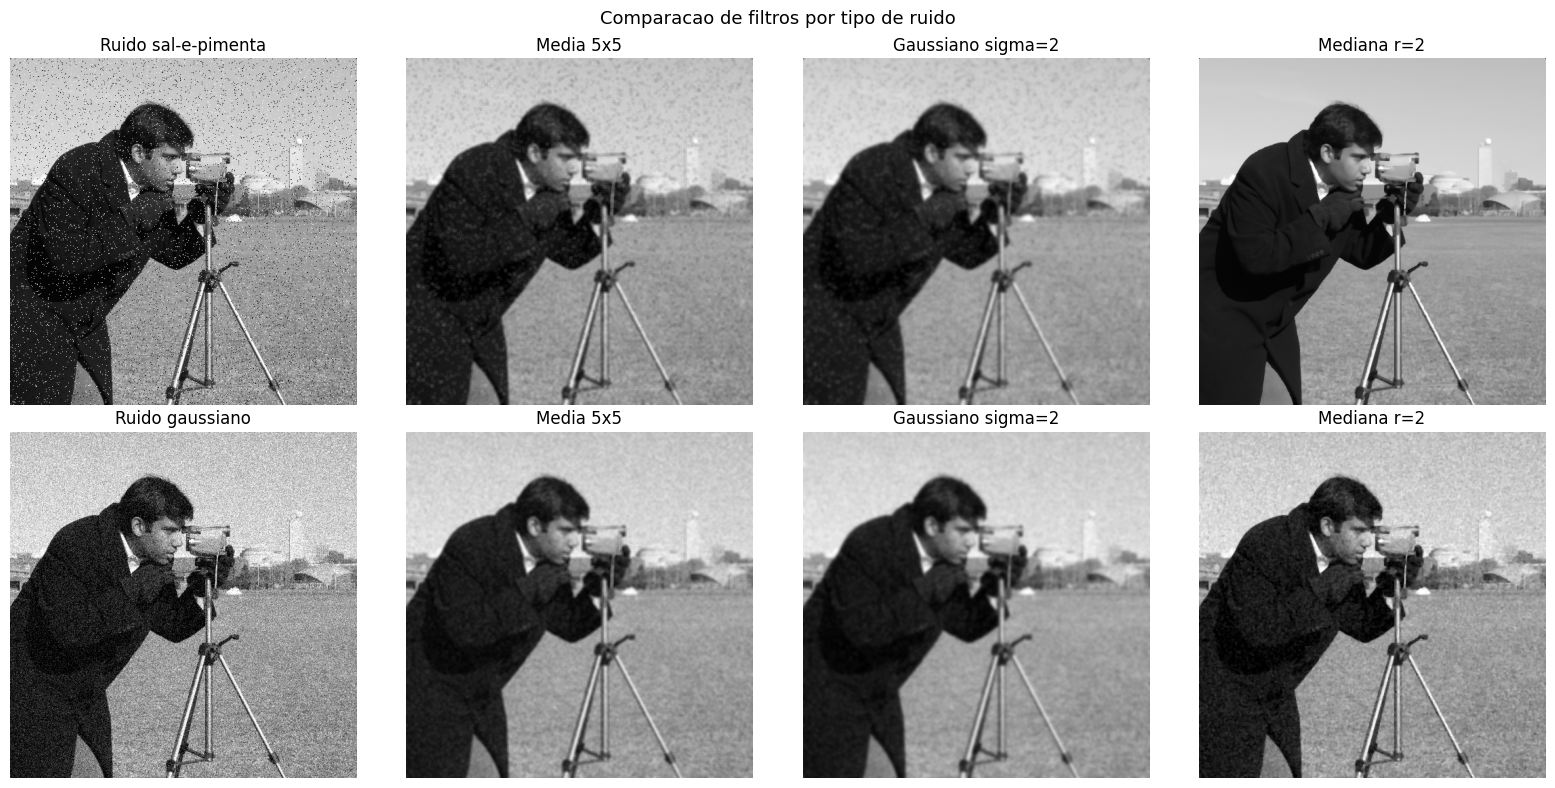

In [17]:
from skimage import data
from skimage.util import random_noise
from skimage.filters import gaussian, median
from skimage.morphology import disk

# carregar imagem e normalizar para [0,1]
img = data.camera().astype(float) / 255.0  

# adicionar ruídos
img_sp  = random_noise(img, mode='s&p', amount=0.05)
img_gau = random_noise(img, mode='gaussian', var=0.01)


fig, axes = plt.subplots(2, 4, figsize=(16, 8))
rows = [(img_sp, 'Ruido sal-e-pimenta'), (img_gau, 'Ruido gaussiano')]

for row_idx, (noisy, label) in enumerate(rows):
    axes[row_idx, 0].imshow(noisy, cmap='gray')
    axes[row_idx, 0].set_title(label)

    mean5 = convolve(noisy, np.ones((5,5))/25, mode='reflect')
    axes[row_idx, 1].imshow(mean5, cmap='gray')
    axes[row_idx, 1].set_title('Media 5x5')

    gauss = gaussian(noisy, sigma=2)
    axes[row_idx, 2].imshow(gauss, cmap='gray')
    axes[row_idx, 2].set_title('Gaussiano sigma=2')

    med = median(noisy, disk(2))
    axes[row_idx, 3].imshow(med, cmap='gray')
    axes[row_idx, 3].set_title('Mediana r=2')

for ax in axes.flat: ax.axis('off')
plt.suptitle('Comparacao de filtros por tipo de ruido', fontsize=13)
plt.tight_layout()
plt.show()


---
## 3.5 Filtros de Nitidez e Realce

### 3.5.1 Laplaciano

$$\nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}$$

Kernels discretos:

$$w_4 = \begin{pmatrix}0&1&0\\1&-4&1\\0&1&0\end{pmatrix} \qquad
w_8 = \begin{pmatrix}1&1&1\\1&-8&1\\1&1&1\end{pmatrix}$$

### 3.5.2 Unsharp Masking e High-Boost

$$g = f + k\,(f - \bar{f}), \quad k \ge 1$$

Para $k=1$: unsharp masking. Para $k>1$: high-boost filtering.

### 3.5.3 Gradiente -- Sobel e Prewitt

$$G_x = \begin{pmatrix}-1&0&1\\-2&0&2\\-1&0&1\end{pmatrix} \qquad
G_y = \begin{pmatrix}-1&-2&-1\\0&0&0\\1&2&1\end{pmatrix}$$

Magnitude: $M = \sqrt{G_x^2 + G_y^2}$


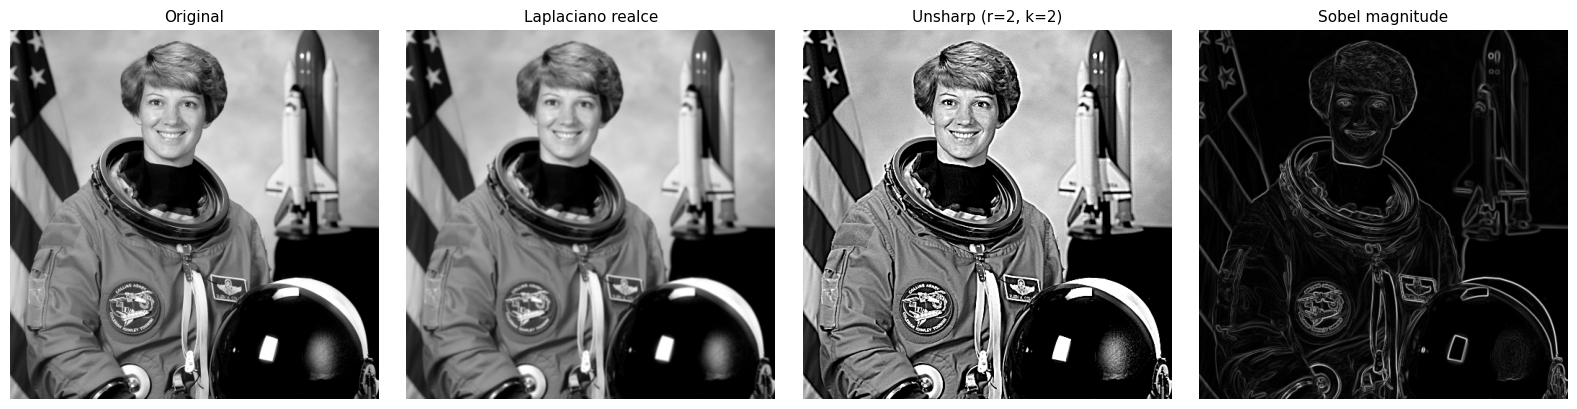

In [18]:
from skimage.filters import laplace, sobel, unsharp_mask

img = color.rgb2gray(data.astronaut())  # dominio publico (skimage)

lap      = laplace(img)
enhanced = img - 0.3 * lap
enhanced = np.clip(enhanced, 0, 1)
unsharp  = unsharp_mask(img, radius=2, amount=2.0)
sob      = sobel(img)

show(
    [img, enhanced, unsharp, sob],
    ['Original', 'Laplaciano realce', 'Unsharp (r=2, k=2)', 'Sobel magnitude']
)


---
## 3.6 Detector de Bordas de Canny

O detector de Canny (1986) minimiza tres criterios:

1. **Boa deteccao** -- baixa taxa de falsos positivos e negativos
2. **Boa localizacao** -- bordas detectadas proximas as reais
3. **Resposta unica** -- cada borda gera exatamente um ponto

### Algoritmo passo a passo

```
1. Suavizacao Gaussiana        -> reduz ruido
2. Gradiente (Sobel)           -> magnitude M e angulo theta
3. Supressao de nao-maximos    -> afina bordas a 1 pixel
4. Histerese dupla (T_low, T_high) -> mantem bordas continuas
```

> **Por que dois limiares?** Pixels com $M > T_{high}$ sao bordas fortes. Pixels com
> $T_{low} < M < T_{high}$ sao bordas fracas -- mantidos so se conectados a uma borda forte.


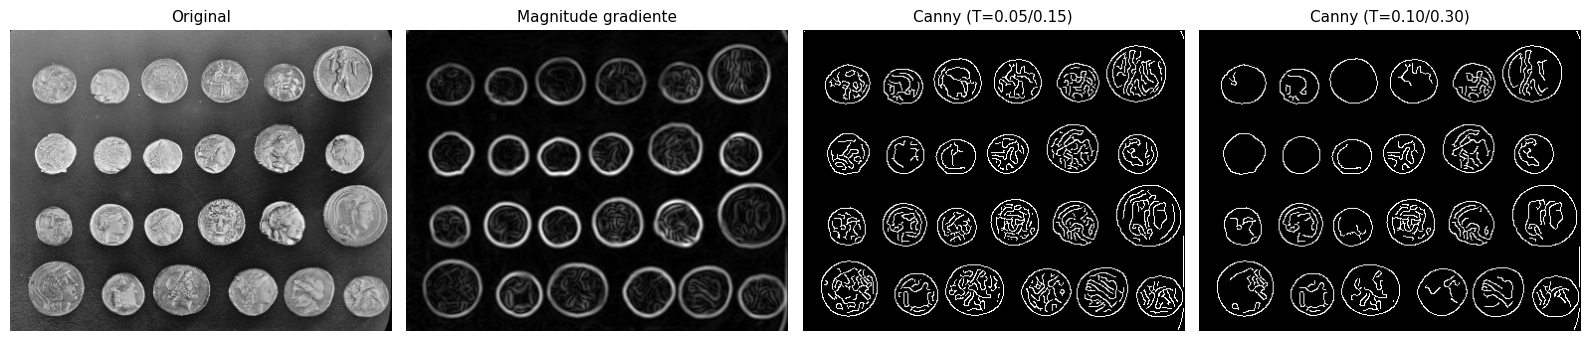

In [19]:
from skimage.feature import canny
from skimage.filters import gaussian, sobel_h, sobel_v

img = data.coins().astype(float) / 255.0  # dominio publico (skimage)

blurred   = gaussian(img, sigma=1.5)
Gx        = sobel_h(blurred)
Gy        = sobel_v(blurred)
magnitude = np.sqrt(Gx**2 + Gy**2)

edges_loose  = canny(img, sigma=1.5, low_threshold=0.05, high_threshold=0.15)
edges_strict = canny(img, sigma=1.5, low_threshold=0.10, high_threshold=0.30)

show(
    [img, magnitude, edges_loose, edges_strict],
    ['Original', 'Magnitude gradiente',
     'Canny (T=0.05/0.15)', 'Canny (T=0.10/0.30)']
)


---
## 3.7 Morfologia Matematica

A morfologia matematica trata imagens como **conjuntos** e usa um
**elemento estruturante** $B$ para sondar a forma dos objetos.

### 3.7.1 Erosao e Dilatacao

$$\text{Erosao:}\quad (A \ominus B)(x,y) = \min_{(s,t)\in B} f(x+s, y+t)$$
$$\text{Dilatacao:}\quad (A \oplus B)(x,y) = \max_{(s,t)\in B} f(x+s, y+t)$$

| Operacao | Efeito em binaria | Efeito em tons de cinza |
|---|---|---|
| Erosao | Encolhe objetos, remove pontos isolados | Escurece |
| Dilatacao | Expande objetos, preenche buracos | Clareia |

### 3.7.2 Abertura e Fechamento

$$\text{Abertura: } A \circ B = (A \ominus B) \oplus B$$
$$\text{Fechamento: } A \bullet B = (A \oplus B) \ominus B$$

- **Abertura**: remove ruido fino, preserva forma geral
- **Fechamento**: fecha buracos e fissuras

### 3.7.3 Gradiente Morfologico

$$\text{Gradiente} = (A \oplus B) - (A \ominus B)$$

### 3.7.4 Top-Hat e Black-Hat

$$\text{Top-Hat} = f - (f \circ B) \quad\text{(realca picos finos)}$$
$$\text{Black-Hat} = (f \bullet B) - f \quad\text{(realca vales finos)}$$

> Aplicacao medica: o Top-Hat branco realca microcalcificacoes em mamografias.


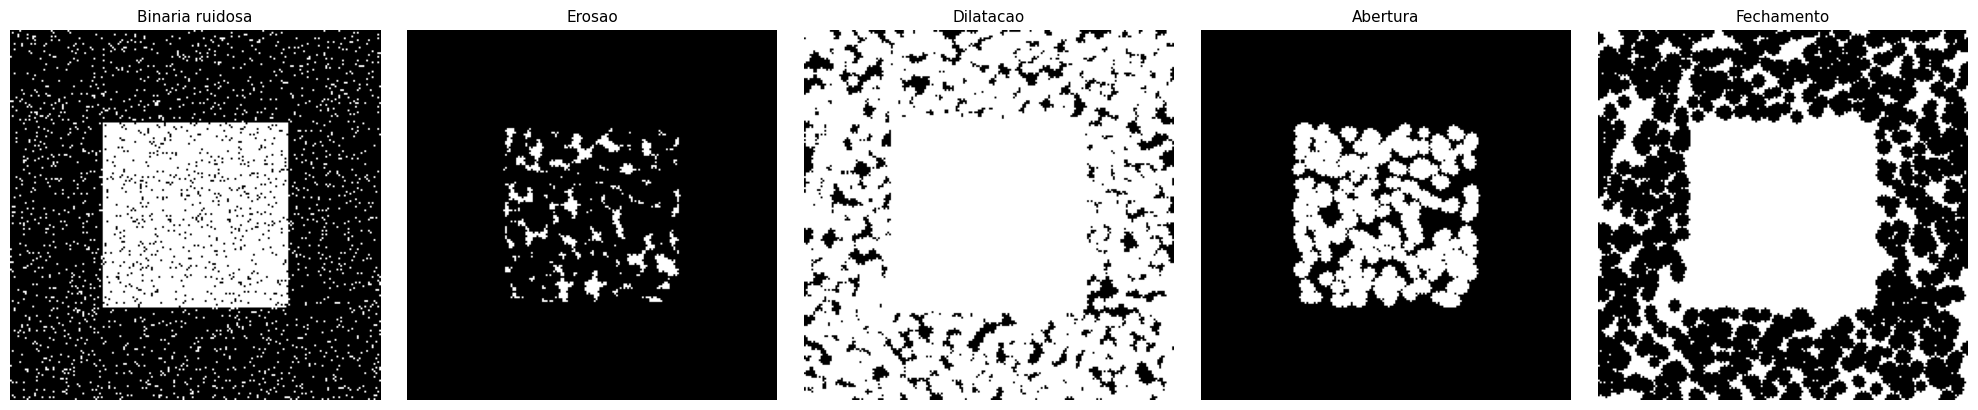

In [20]:
from skimage.morphology import (
    disk, erosion, dilation, opening, closing,
    white_tophat, black_tophat
)

# Imagem binaria ruidosa sintetica
rng = np.random.default_rng(42)
base = np.zeros((200, 200), dtype=np.uint8)
base[50:150, 50:150] = 255
noise_mask = rng.random(base.shape) > 0.94
img_bin = base.copy()
img_bin[noise_mask] = 255 - img_bin[noise_mask]

se = disk(3)
show(
    [img_bin, erosion(img_bin, se), dilation(img_bin, se),
     opening(img_bin, se), closing(img_bin, se)],
    ['Binaria ruidosa', 'Erosao', 'Dilatacao', 'Abertura', 'Fechamento']
)


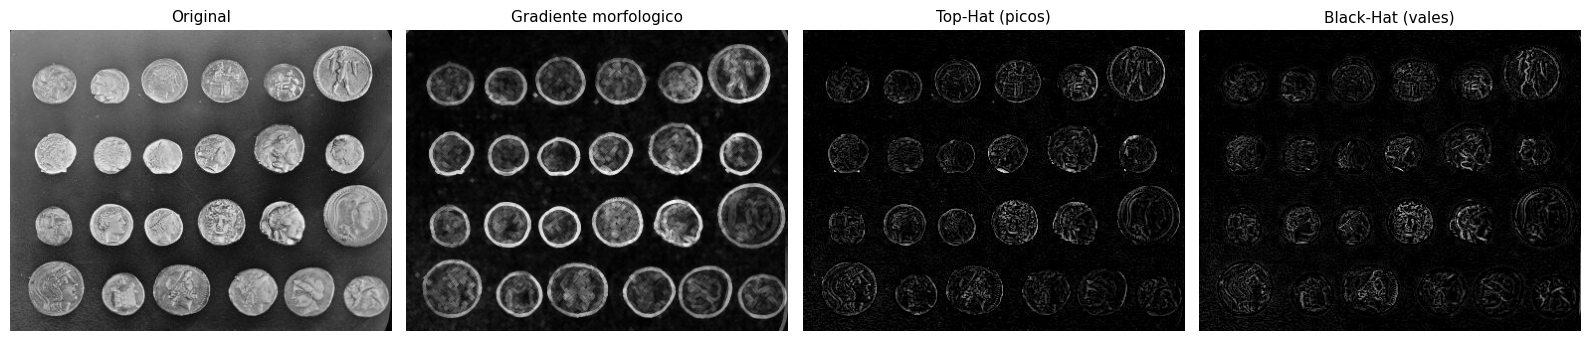

In [21]:
# Gradiente morfologico e Top-Hat em tons de cinza
img_gray = data.coins()
se = disk(2)

grad_morph = dilation(img_gray, se).astype(int) - erosion(img_gray, se).astype(int)
tophat     = white_tophat(img_gray, se)
blackhat   = black_tophat(img_gray, se)

show(
    [img_gray, grad_morph, tophat, blackhat],
    ['Original', 'Gradiente morfologico', 'Top-Hat (picos)', 'Black-Hat (vales)']
)


---
## 3.8 Pipeline Completo: Da Imagem Bruta ao Contorno

Reunindo os conceitos: suavizacao -> deteccao de bordas -> morfologia.

Usamos `skimage.data.page()` (texto tipografico, dominio publico),
que simula um documento OCR ruidoso.


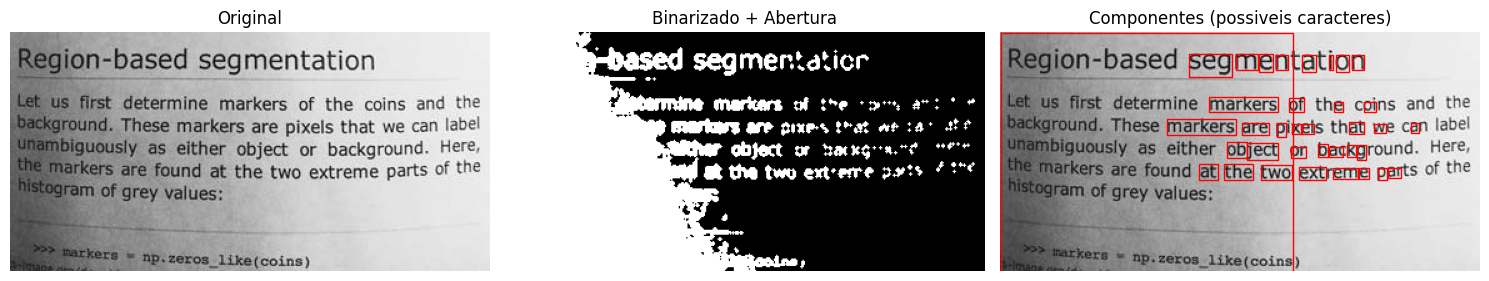

Componentes encontrados: 96


In [22]:
from skimage.data import page
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.filters import gaussian
import matplotlib.patches as mpatches

doc = page()

# 1. Suavizacao leve
smooth = gaussian(doc.astype(float)/255, sigma=0.8)

# 2. Binarizacao (Otsu)
thresh = threshold_otsu(smooth)
binary = smooth < thresh  # texto e escuro

# 3. Abertura morfologica
from skimage.morphology import opening, disk
cleaned = opening(binary, disk(1))

# 4. Rotulagem de componentes conexos
labeled = label(cleaned)
regions = regionprops(labeled)

# 5. Visualizacao com bounding boxes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(doc, cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(cleaned, cmap='gray'); axes[1].set_title('Binarizado + Abertura')
axes[2].imshow(doc, cmap='gray')
areas = sorted(regions, key=lambda r: r.area, reverse=True)[:40]
for r in areas:
    if r.area > 30:
        y0, x0, y1, x1 = r.bbox
        rect = mpatches.Rectangle((x0, y0), x1-x0, y1-y0,
                                   fill=False, edgecolor='red', linewidth=1)
        axes[2].add_patch(rect)
axes[2].set_title('Componentes (possiveis caracteres)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Componentes encontrados: {len(regions)}')


---
## 3.9 Como usar imagens sem restricao de copyright

Este livro usa exclusivamente imagens **livres de direitos autorais**.
Fontes recomendadas:

| Fonte | Tipo | Licenca | URL |
|---|---|---|---|
| `scikit-image` (data.*) | Cientificas classicas | BSD/CC0 | built-in |
| `OpenCV` samples | Variadas | Apache 2.0 | built-in |
| NIH Open-i | Medicas (raio-X, MRI) | CC0 | openi.nlm.nih.gov |
| Unsplash | Fotograficas | Unsplash License | unsplash.com |
| NASA Image Gallery | Satelite/Espaco | CC0/dominio publico | images.nasa.gov |
| Wikimedia Commons | Variadas | CC/dominio publico | commons.wikimedia.org |
| MNIST/CIFAR-10 | ML datasets | CC0 | built-in (PyTorch/TF) |

```python
# Listar todas as imagens disponiveis no scikit-image
import skimage.data as skd
print([f for f in dir(skd) if not f.startswith('_')])
```


---
## 3.10 Resumo

| Topico | O que aprendemos | Onde aplicar |
|---|---|---|
| Convolucao 2D | Operacao fundamental, kernels, padding | Todos os filtros lineares |
| Filtros passa-baixa | Media, Gaussiano, Mediana | Pre-processamento, reducao de ruido |
| Filtros passa-alta | Laplaciano, Sobel, Unsharp | Realce, deteccao de bordas |
| Canny | Pipeline de deteccao em 4 etapas | Segmentacao, OCR, VC |
| Morfologia | Erosao, dilatacao, abertura, fechamento | Pos-processamento segmentacao |
| Pipeline completo | Suavizacao->limiar->morfo->bbox | OCR, biometria, medicina |

### Conexoes para os proximos capitulos

```
Cap. 3 (Filtragem)  ->  Cap. 4 (Segmentacao avancada: Watershed, K-means)
Cap. 3 (Convolucao) ->  Cap. 5 (Fourier: convolucao = multiplicacao espectral)
Cap. 3 (Kernels)    ->  Cap. 9 (CNNs aprendem kernels automaticamente!)
```


---
## 3.11 Uso do NotebookLM como Tutor Complementar

Para aprofundar os topicos deste capitulo com o NotebookLM:

- *"Explique a diferenca entre convolucao e correlacao com exemplos numericos 3x3."*
- *"Por que o filtro de mediana preserva bordas melhor que o gaussiano?"*
- *"Quais sao os tres criterios que o detector de Canny otimiza?"*
- *"Como a abertura morfologica remove ruido sem destruir formas grandes?"*
- *"De exemplos de aplicacoes medicas de Top-Hat em mamografia."*


---
## 3.12 Lista de Exercicios Teoricos

1. Calcule manualmente a convolucao da imagem $3\times3$ com o kernel Laplaciano $w_4$:
   $$f = \begin{pmatrix}0&0&0\\0&1&0\\0&0&0\end{pmatrix}$$

2. Explique por que $\sigma$ grande no filtro Gaussiano pode prejudicar a deteccao de objetos pequenos.

3. Demonstre que abertura morfologica e idempotente: $(A \circ B) \circ B = A \circ B$.

4. Compare o gradiente morfologico com o Sobel: quais as vantagens de cada um?

5. (Avancado -- pos) Mostre que a convolucao com Gaussiano corresponde a uma
   multiplicacao por uma Gaussiana no dominio de Fourier (Teorema da Convolucao).


---
## 3.13 Exercicios de Programacao (EPs)

### EP03_01 -- Convolucao 2D do zero
Implemente `conv2d(img, kernel, pad_mode)` sem usar `scipy` nem `cv2`.
Valide comparando com `scipy.ndimage.convolve` em kernels de media e Laplaciano.

### EP03_02 -- Analise do parametro sigma no filtro Gaussiano
Para sigma em {0.5, 1, 2, 4, 8}, filtre `data.camera()`, calcule o PSNR
em relacao ao original e plote *sigma x PSNR*. O que voce observa?

### EP03_03 -- Comparacao de filtros em ruido
Dado `img_sp` (sal-e-pimenta 10%) e `img_gauss` (gaussiano var=0.1),
compare media 5x5, gaussiano sigma=2 e mediana r=2 usando MSE e SSIM.

### EP03_04 -- Detector de bordas comparativo
Aplique Sobel, Prewitt, Laplaciano e Canny em `data.coins()`.
Para Canny, varie T_high em {0.1, 0.2, 0.3} e mostre o efeito.

### EP03_05 -- Erosao e dilatacao do zero
Implemente `erosion_manual(img, se)` e `dilation_manual(img, se)` usando
apenas NumPy. Valide com `skimage.morphology.erosion`.

### EP03_06 (Avancado) -- Top-Hat para realce de microcalcificacoes
Baixe uma imagem de mamografia publica (INbreast ou similar, CC0).
Aplique o Top-Hat branco com elementos estruturantes de tamanhos variados
e discuta qual melhor realca as microcalcificacoes.

### EP03_07 (Avancado) -- Pipeline OCR minimo
Usando `data.page()`, implemente o pipeline completo:
Gaussiano -> Otsu -> Abertura -> Componentes conexos -> Ordenar por posicao.
Exiba bounding boxes e tente usar Tesseract-OCR na imagem pre-processada.


---
# Proposta Completa -- 10 Capitulos (PDI + VC)

---

## Parte I -- Processamento Digital de Imagens (PDI)

| Cap. | Titulo | Conceitos-chave |
|---|---|---|
| 1 | **Fundamentos e Primeiros Passos** | Imagem digital, pixels, matrizes, limiarizacao, Otsu |
| 2 | **Da Captura ao Pixel** | Visao humana, sensores, amostragem, quantizacao, conectividade, transformacoes geometricas |
| 3 | **Filtragem Espacial e Morfologia** | Convolucao, suavizacao, nitidez, Canny, erosao/dilatacao |
| 4 | **Histograma, Realce e Restauracao** | Histograma, equalizacao (CLAHE), modelos de ruido, filtro de Wiener, bilateral |
| 5 | **Frequencia, Wavelets e Compressao** | DFT 2D, filtragem espectral, Wavelets, DCT, JPEG |

---

## Parte II -- Visao Computacional (VC)

### Capitulo 6 -- Caracteristicas e Descritores Locais

**Motivacao:** reconhecer objetos em condicoes adversas (rotacao, escala, iluminacao).

| Secao | Conteudo |
|---|---|
| 6.1 | Deteccao de pontos de interesse: Harris, Shi-Tomasi |
| 6.2 | Descritores invariantes: SIFT, SURF, ORB |
| 6.3 | Histograma de Gradientes Orientados (HOG) |
| 6.4 | Texturas: LBP, GLCM, filtros de Gabor |
| 6.5 | Casamento de pontos (matching) e RANSAC |
| 6.6 | Apps reais: panoramas, realidade aumentada, busca visual por imagem |
| EPs | Harris do zero; pipeline de matching panoramico; HOG para pedestres |

---

### Capitulo 7 -- Segmentacao Avancada

**Motivacao:** separar objetos de interesse -- de celulas microscopicas a carros no transito.

| Secao | Conteudo |
|---|---|
| 7.1 | Limiarizacao adaptativa e Otsu multi-nivel |
| 7.2 | Crescimento de regioes e divisao/fusao (split and merge) |
| 7.3 | Algoritmo Watershed -- teoria e implementacao |
| 7.4 | Clusterizacao: K-means, GMM, SLIC (superpixels) |
| 7.5 | Introducao a segmentacao semantica com deep learning |
| 7.6 | Apps reais: contagem de celulas, segmentacao de lesoes dermatologicas |
| EPs | Watershed interativo; K-means em espaco de cor; comparacao com GrabCut |

---

### Capitulo 8 -- Geometria de Multiplas Vistas e Visao 3D

**Motivacao:** reconstruir o mundo 3D a partir de imagens 2D -- robotica, veiculos autonomos.

| Secao | Conteudo |
|---|---|
| 8.1 | Modelo pinhole, parametros intrinsecos e extrinsecos |
| 8.2 | Calibracao de camera (Zhang / chessboard) |
| 8.3 | Geometria epipolar, matriz fundamental e essencial |
| 8.4 | Visao estereo e mapa de disparidade |
| 8.5 | Estrutura a partir do Movimento (SfM) -- introducao |
| 8.6 | Sensores de profundidade: LiDAR, ToF, RGB-D |
| 8.7 | Apps reais: mapeamento 3D, realidade aumentada, veiculos autonomos |
| EPs | Calibracao com OpenCV; mapa de disparidade estereo; nuvem de pontos |

---

### Capitulo 9 -- Aprendizado Profundo para Visao

**Motivacao:** como as CNNs aprendem os kernels dos capitulos 3-6 automaticamente?

| Secao | Conteudo |
|---|---|
| 9.1 | Da convolucao manual ao kernel aprendivel |
| 9.2 | Arquitetura CNN: conv, pooling, BN, dropout |
| 9.3 | Transfer Learning: ResNet, EfficientNet, ViT |
| 9.4 | Deteccao de objetos: YOLO, SSD, DETR |
| 9.5 | Segmentacao semantica e de instancia: U-Net, Mask R-CNN |
| 9.6 | Modelos fundacao multimodais (CLIP, SAM) |
| 9.7 | Apps reais: deteccao de tumores, classificacao de doencas retinianas |
| EPs | CNN simples no MNIST; fine-tuning ResNet em dataset medico; SAM interativo |

---

### Capitulo 10 -- Aplicacoes Integradoras

**Motivacao:** problemas reais exigem pipelines completos -- da aquisicao ao resultado.

| Secao | Projeto |
|---|---|
| 10.1 | OCR de documentos: pre-proc -> segmentacao -> Tesseract -> pos-proc |
| 10.2 | Biometria facial: deteccao (MTCNN) -> alinhamento -> embeddings |
| 10.3 | Analise de microscopia: celulas, metalografia, contar e classificar |
| 10.4 | Reconhecimento de placas (ALPR): camera -> YOLO -> OCR |
| 10.5 | Visao robotica: controle visual, servo-visao, navegacao |
| 10.6 | Etica e vies em VC: datasets tendenciosos, explicabilidade, LGPD |
| EPs | Projeto integrador escolhido pelo aluno; relatorio tecnico + codigo |

---

## Diferenciacao Graduacao x Pos-Graduacao

| Icone | Publico | Profundidade |
|---|---|---|
| (basico) | Graduacao | Conceito + implementacao pratica |
| (intermediario) | Ambos | Teoria + codigo intermediario |
| (avancado) | Pos-Graduacao | Derivacoes, artigos, projetos de pesquisa |

Na pos, cada capitulo inclui:
- 1-2 artigos seminais obrigatorios (links para arXiv/DOI)
- Analise comparativa de metodos (tabelas de benchmarks)
- Projeto de pesquisa incremental ao longo do semestre
